# Tarea 1 2026
##### Alumno: Álvaro Contreras Zúñiga
##### Matrícula: 2021433031

### Pregunta 1: Carga, Limpieza y Selección de Variables


In [18]:
# Importamos todas las librerías necesarias para manejo de datos, gráficos y modelamiento econométrico.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Silenciamos advertencias estéticas menores
import warnings
warnings.filterwarnings("ignore")

# 1. Cargamos la base de datos CSV a un DataFrame
df = pd.read_csv('student_productivity.csv')


#### Exploración de Variables: Estadísticas Descriptivas y Distribución
Como paso preliminar, analizaremos la tendencia central, dispersión y forma distributiva de toda la muestra que nos entregará una noción del comportamiento de los alumnos previo a la limpieza geométrica.


In [19]:
# A. Tabla de Estadísticas Descriptivas (Medias, Varianzas, Mínimos y Máximos)
print("--- Estadísticas Descriptivas Generales ---")
display(df.drop(columns=['student_id']).describe())


--- Estadísticas Descriptivas Generales ---


,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,caffeine_intake_mg,upcoming_deadline,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
count,4973.000000,5047.000000,4954.000000,4939.000000,4965.000000,4965.000000,5068.000000,5035.000000,5021.000000,4904.000000,4946.000000,1518.000000,4988.000000,4905.000000,4983.000000,4912.000000
mean,20.510557,4.538708,2.480454,2.012296,3.002872,1.571458,7.023301,6.979045,250.804820,0.501223,5.516983,0.661397,29.388119,45.633156,37.313526,18.840542
std,2.876399,1.819412,1.178094,0.983104,1.472740,1.112557,1.159948,2.482912,143.685652,0.500049,2.873859,0.473391,9.996024,14.257283,16.841997,12.119456
min,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,18.000000,3.260000,1.660000,1.320000,2.000000,0.680000,6.250000,5.280000,129.000000,0.000000,3.000000,0.000000,22.460000,35.770000,25.330000,9.410000
50%,20.000000,4.530000,2.480000,2.010000,2.990000,1.500000,7.015000,6.950000,251.000000,1.000000,5.000000,1.000000,29.380000,45.650000,36.920000,17.990000
75%,23.000000,5.760000,3.280000,2.690000,4.030000,2.350000,7.820000,8.705000,375.000000,1.000000,8.000000,1.000000,36.232500,55.410000,49.200000,27.410000
max,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,499.000000,1.000000,10.000000,1.000000,63.480000,97.580000,98.020000,64.090000


**Interpretación Descriptiva Inicial:** Al revisar la tabla superior podemos hacernos una idea clara de nuestra muestra: en promedio, los encuestados tienen 20.5 años, dedican unas 4.5 horas diarias a estudiar de forma autónoma y logran dormir alrededor de 7 horas por noche. La desviación estándar nos indica que los datos están dentro de lo esperable y no hay valores imposibles. A continuación, revisaremos esta distribución de manera visual usando histogramas para observar cómo se agrupan los estudiantes.


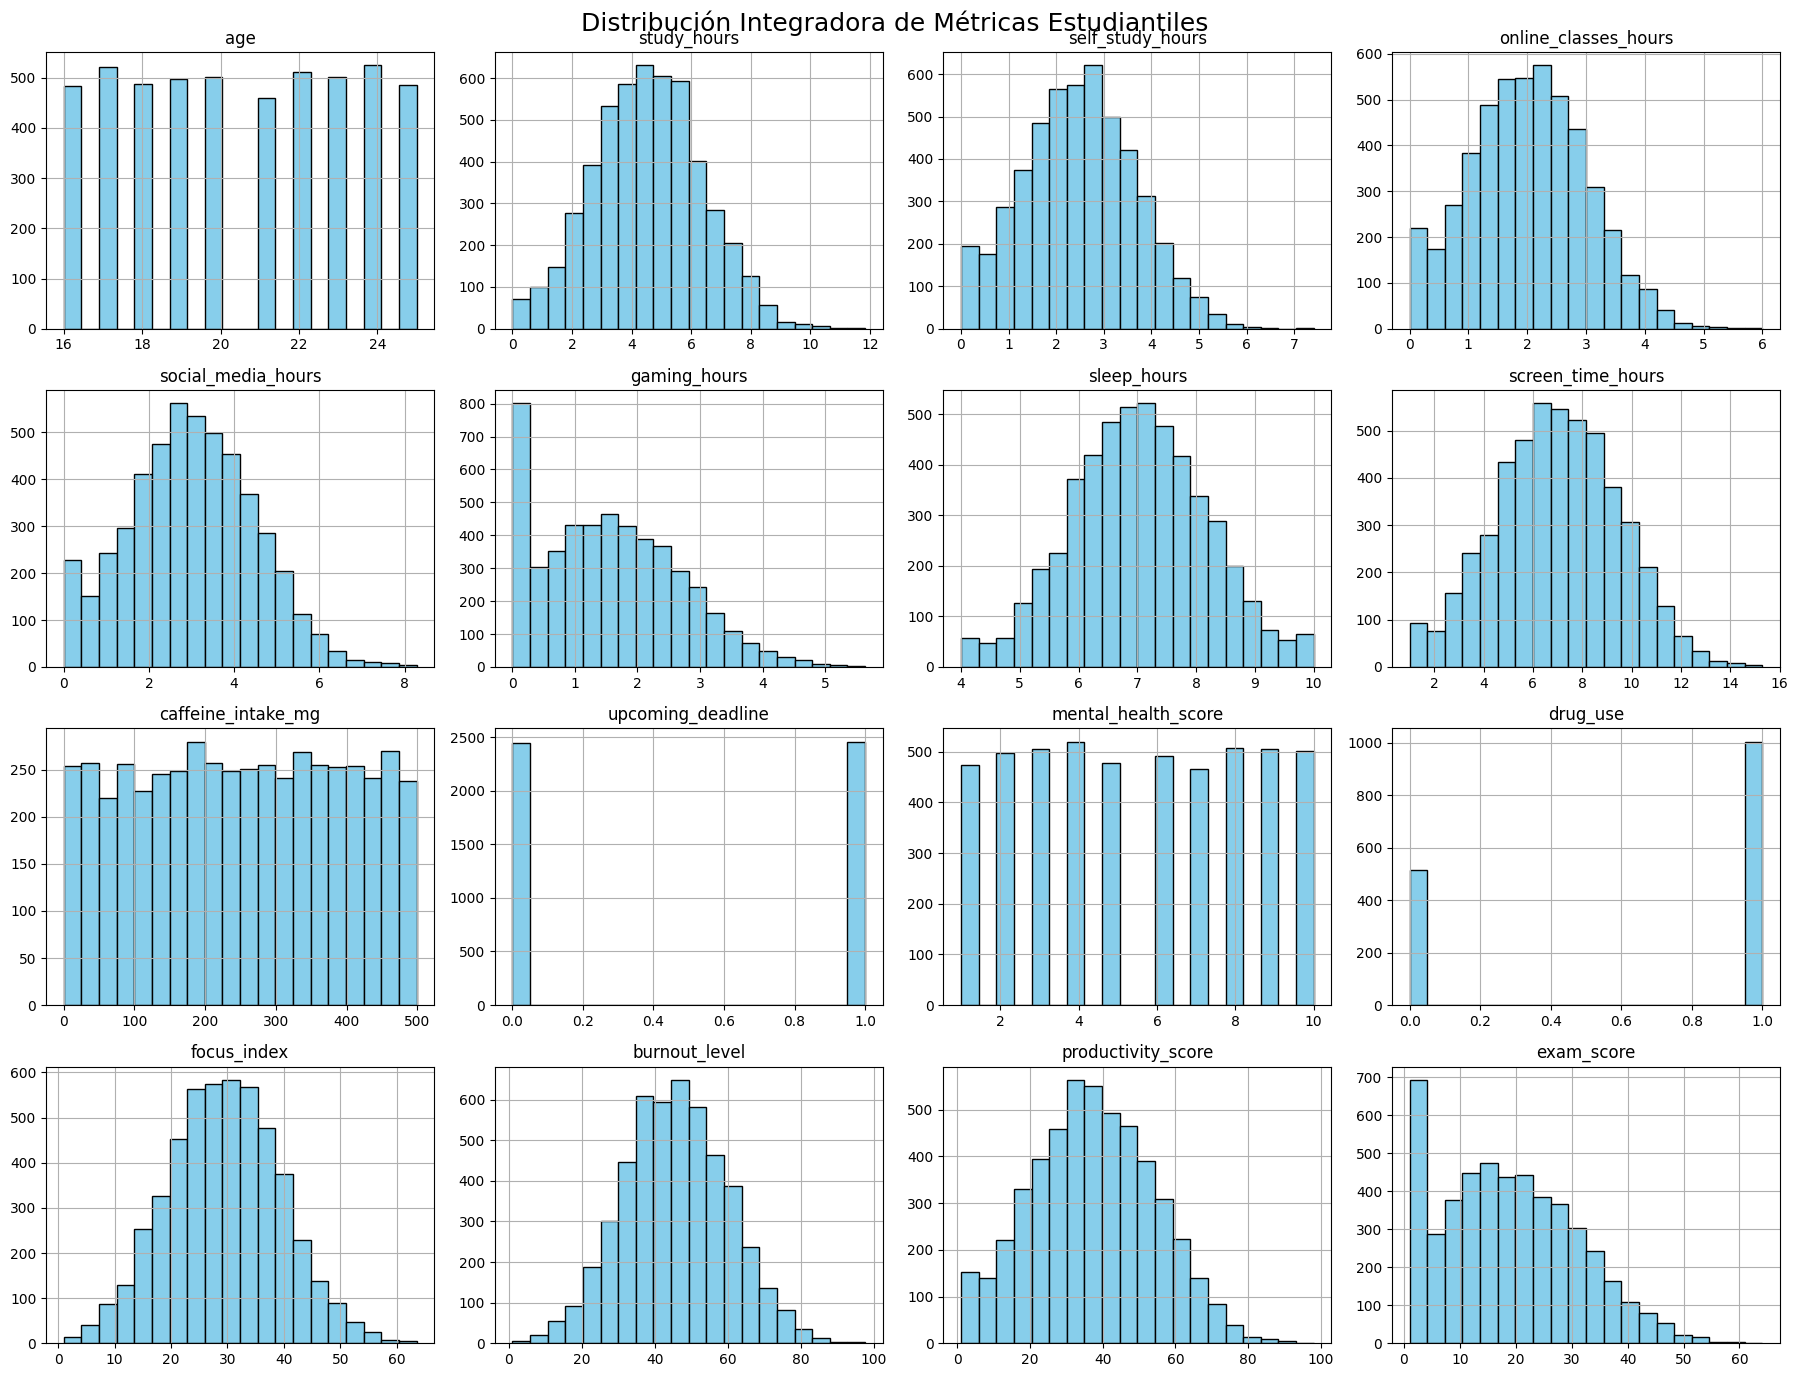

In [20]:
# B. Cuadrícula Visual de Distribución de la Muestra
df.drop(columns=['student_id']).hist(figsize=(18, 14), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribución Integradora de Métricas Estudiantiles', fontsize=18)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


#### Análisis de Integridad y Diagnóstico de la Muestra
Tras la carga inicial del dataset "student_productivity.csv", se procedió a realizar un diagnóstico rápido para evaluar la consistencia de las variables y revisar si había datos faltantes o nulos en la muestra. Los hallazgos principales son los siguientes


--- Estructura y Datos Faltantes Iniciales ---
                     Tipo de Dato  Valores Nulos  % de Faltantes
student_id                  int64              0        0.000000
age                       float64            648       11.528198
gender                        str            558        9.927059
academic_level                str            630       11.207970
study_hours               float64            574       10.211706
self_study_hours          float64            667       11.866216
online_classes_hours      float64            682       12.133072
social_media_hours        float64            656       11.670521
gaming_hours              float64            656       11.670521
sleep_hours               float64            553        9.838107
screen_time_hours         float64            586       10.425191
exercise_minutes              str            599       10.656467
caffeine_intake_mg        float64            600       10.674257
part_time_job                 str          

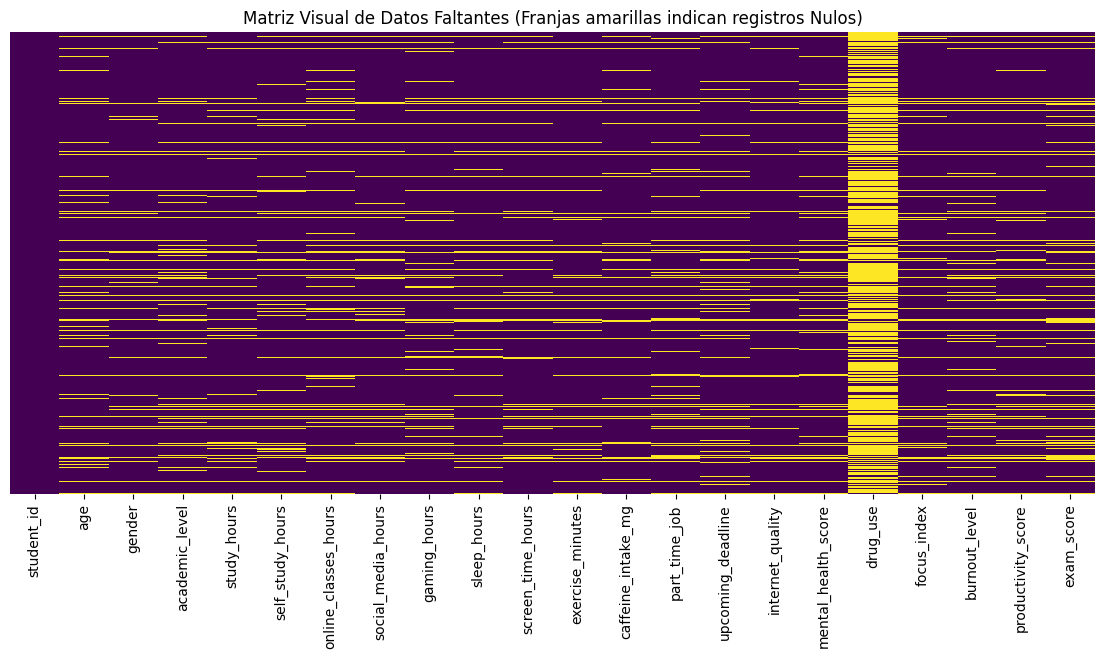

In [21]:
# 2. Vemos la estructura general y cuántos datos faltan por columna para justificar la limpieza
print("--- Estructura y Datos Faltantes Iniciales ---")
diagnostico = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores Nulos': df.isnull().sum(),
    '% de Faltantes': (df.isnull().sum() / len(df)) * 100
})
print(diagnostico)

# Gráfico visual de mapeo de nulos para identificar patrones de pérdida de información
plt.figure(figsize=(14, 6))
# Usamos un mapa de calor donde los valores Nulos resaltarán en otro color
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Matriz Visual de Datos Faltantes (Franjas amarillas indican registros Nulos)')
plt.show()


**Evaluación de Datos Faltantes:** Como se comprueba en el output y franjas del gráfico anterior, se identificó una pérdida crítica de información en la variable "drug_use", la cual presenta un 72.99% de valores nulos (toda la barra amarilla). Aplicar una eliminación automática de todas las observaciones con datos faltantes nos costaría una cantidad altísima de información útil. Descartar filas completas solo por un campo vacío no solo achicaría nuestra muestra artificialmente, sino que afectaría severamente la precisión de nuestros cálculos y le quitaría representatividad a los modelos.

**Inconsistencia en Tipos de Datos:** La variable "exercise_minutes" fue identificada en la tabla como tipo object (cadena de caracteres) en lugar de un tipo numérico continuo (float64), esto sugiere la presencia de errores de digitación o caracteres no numéricos que requieren un proceso de conversión y limpieza antes de ser integrados en cualquier análisis.

**Distribución de Atrición General:** Las variables predictoras fundamentales, tales como "study_hours", "mental_health_score" y "productivity_score", exhiben niveles de omisión situados entre el 10% y el 12% (franjas amarillas aleatorias menores), donde si bien este margen es manejable, refuerza la necesidad de una estrategia de limpieza focalizada.


In [22]:
# Homogeneización de Variables Evidentes (exercise_minutes y part_time_job)

# Para los minutos de ejercicio, quitamos la palabra "min" y espacios sobrantes para dejar solo el número.
# Luego, forzamos la variable a ser de tipo numérico (si hay textos extraños, los vuelve NaN).
df['exercise_minutes'] = df['exercise_minutes'].str.replace('min', '', case=False).str.strip()
df['exercise_minutes'] = pd.to_numeric(df['exercise_minutes'], errors='coerce')

# Para el trabajo part-time, pasamos el texto a minúsculas y creamos una variable binaria temporal (1 para yes, 0 para no).
df['part_time_job'] = df['part_time_job'].str.lower().str.strip()
df['part_time_job_bin'] = df['part_time_job'].map({'yes': 1, 'no': 0})


#### Generación de Variable Binaria de Participación (took_test)
De acuerdo con los requerimientos solicitados, se procedió a discriminar la muestra entre aquellos estudiantes que efectivamente rindieron la evaluación final y aquellos que no lo hicieron.

**Metodología (Criterio de Segmentación):** Se definió la variable dependiente binaria "took_test" asignando el valor de 1 a registros con un "exam_score" superior a 1.0, y 0 en caso contrario.




In [23]:
# Creamos la variable target usando np.where: Si la nota > 1.0, asignamos 1 (rindió), si no, 0.
df['took_test'] = np.where(df['exam_score'] > 1.0, 1, 0)

# Verificamos nuestra muestra total antes de los filtros.
print(f"Total observaciones iniciales: {len(df)}")



Total observaciones iniciales: 5621


#### Análisis de Correlación Continuo y la Decisión de Participación
En este primer análisis, examinamos el coeficiente de correlación de las variables continuas y binarias para identificar qué factores se asocian directa o indirectamente con la decisión del estudiante de rendir el examen (took_test).


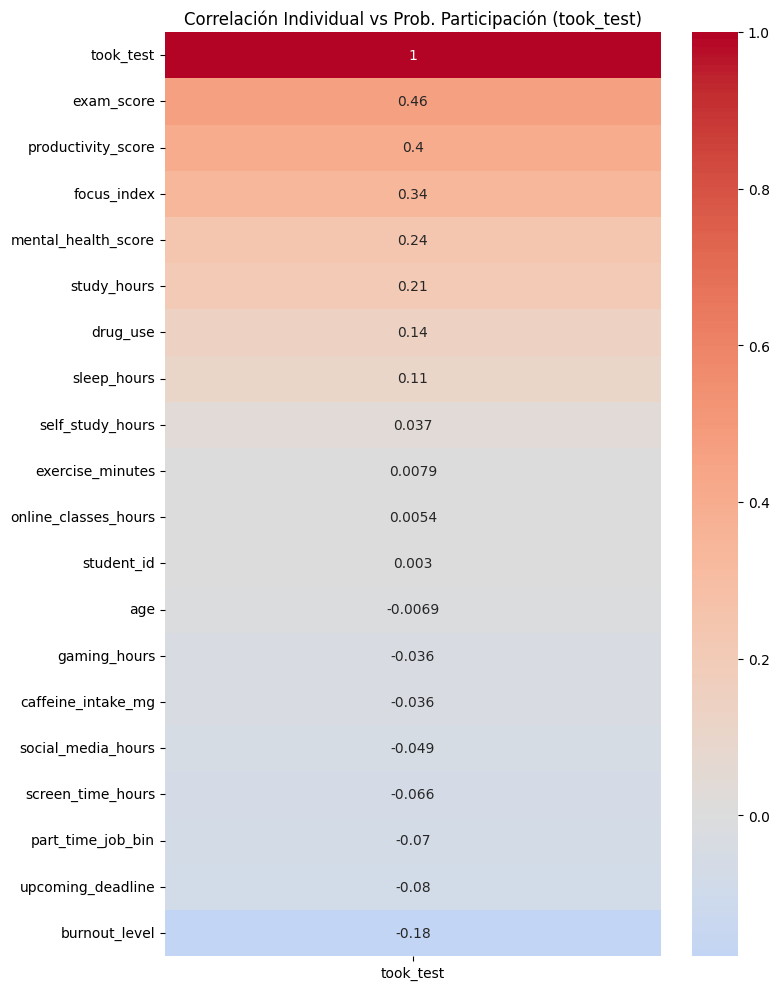

In [24]:
# Obtenemos una lista con todas las columnas que son numéricas en la base
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Configuramos el gráfico lineal
plt.figure(figsize=(8, 12))

# Focalizamos el heatmap solo en la columna 'took_test' y ordenamos para mayor claridad visual
heatmap_data = df[numeric_cols].corr()[['took_test']].sort_values(by='took_test', ascending=False)
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0)

plt.title("Correlación Individual vs Prob. Participación (took_test)")
plt.show()


#### Interpretación de Relaciones
Como se observa en el vector heatmap, se despliegan tendencias comportamentales claras:

1. **Productividad y Enfoque:** El "productivity_score" y el "focus_index" destacan como las variables más influyentes de la tabla, indicando que la capacidad para organizarse y mantener la concentración son los factores clave que animan al alumno a presentarse a rendir el test.
2. **Salud Mental y Preparación:** Se aprecia una asociación positiva relevante en "mental_health_score" y "study_hours", lo que indica que el bienestar psicológico y el tiempo de estudio acumulado también actúan para fomentar la asistencia.
3. **El Efecto del Agotamiento:** Como era de esperar, el "burnout_level" presenta una correlación fuertemente negativa, lo que significa que a mayores niveles de agotamiento general, disminuye agudamente la probabilidad de que el estudiante logre presentarse a la evaluación.

 Como validación extra analítica cruzada, expandiremos con una matriz de calor (Heatmap Integrado) para validar el comportamiento cruzado e independiente real de las variables entre sí.


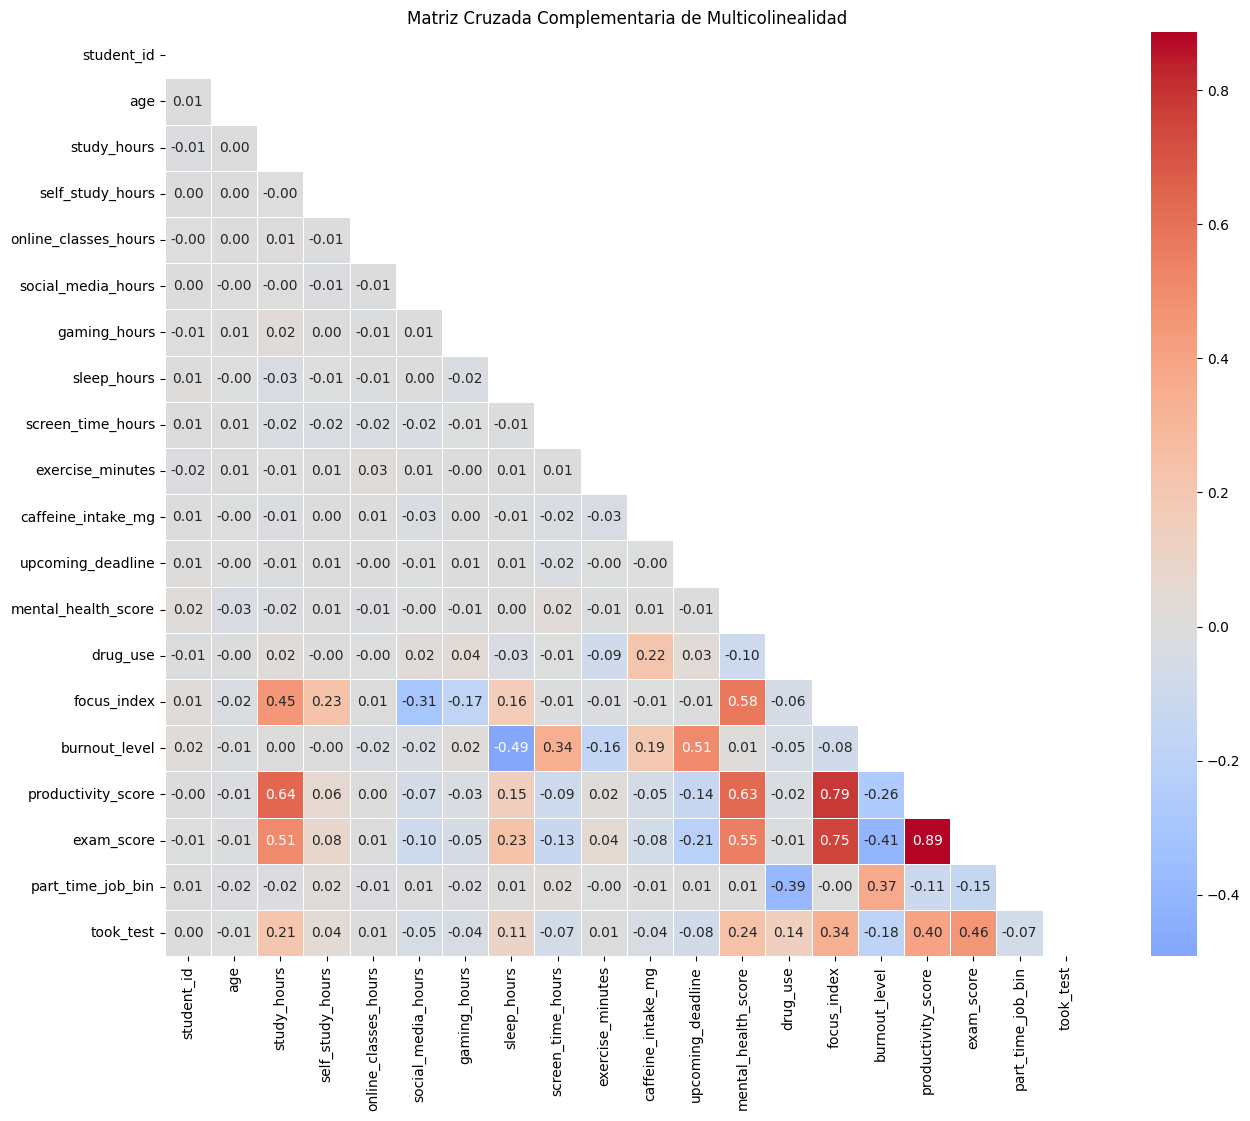

In [25]:
# Matriz Complementaria Computacional completa para observar solapamiento entre todas las predictoras
corr_matrix = df.select_dtypes(include=[np.number]).corr()


plt.figure(figsize=(16, 12))

# Creamos una máscara en forma de triángulo para ocultar la mitad superior (espejo) y simplificar la lectura
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Dibujamos el Heatmap habilitando los números adentro de los cuadros (annot=True) y fijando sus decimales
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True, linewidths=.5)

plt.title('Matriz Cruzada Complementaria de Multicolinealidad')
plt.show()


#### Análisis de Frentes Categóricos (Dummies)
Teniendo las variables analíticas listas, procedemos a realizar la misma validación de aporte estadístico sobre las variables categóricas complejas ("academic_level", "internet_quality" y "gender"). Estas columnas vienen en formato de texto (strings), y por esto se crean variables Dummy (0 y 1) para poder medir estadísticamente su asociación con respecto al target. Cabe recordar que la variable "part_time_job_bin" ya fue generada anteriormente.

Un detalle importante, se dropean los valores NaN estrictamente durante este proceso, la razón analítica detrás de esta decisión es evitar la contaminación de la evaluación, si dejamos esos vacíos, podríamos generar que el modelo asuma una categoría base errónea llena de ceros espurios.


In [26]:
categorias = ['academic_level', 'internet_quality', 'gender']

# Iteramos categoría por categoría de forma aislada
for cat in categorias:
    # 1. Creamos una copia temporal tirando los NaNs SOLO de esa categoría para no contaminar a las demás
    df_temp = df.dropna(subset=[cat, 'took_test'])
    
    # 2. Arreglamos posibles errores de digitación (ej: "High school " a "high school")
    df_temp[cat] = df_temp[cat].astype(str).str.strip().str.lower()
    
    # 3. Construimos variables binarias Dummy y calculamos su correlación
    dummies = pd.get_dummies(df_temp[cat], prefix=cat, drop_first=True)
    corrs = dummies.corrwith(df_temp['took_test'])
    
    print(f"\n--- Correlación Categórica Dummies: {cat} vs took_test ---")
    print(corrs.to_string())



--- Correlación Categórica Dummies: academic_level vs took_test ---
academic_level_postgraduate    -0.010500
academic_level_undergraduate    0.043307

--- Correlación Categórica Dummies: internet_quality vs took_test ---
internet_quality_good    0.014992
internet_quality_poor   -0.017750

--- Correlación Categórica Dummies: gender vs took_test ---
gender_male     0.012188
gender_other   -0.004674


#### Veredicto Final de Selección y Tratamiento Cuantitativo (VIF)
Basándose en la revisión de la Matriz de Correlación, se realiza la selección de las variables que se incluirán en el estudio, el objetivo estratégico es filtrar redundancias y evitar problemas de multicolinealidad que puedan distorsionar las futuras regresiones:

1. **productivity_score**: Se integra lógicamente desde el inicio, ya que es la variable que presenta una mayor correlación directa con el objetivo ($r = 0.40$).
2. **upcoming_deadline**: Se integra desplazando formalmente a "burnout_level". A pesar de que "burnout_level" parecía atractiva en primera instancia, tras un análisis de ruido cruzado, esta poseía intersecciones inmensamente severas (chocaba con "sleep_hours" al 0.49; chocaba con el propio "upcoming_deadline" y además con el trabajo part-time), su inserción, traería graves problemas de multicolinealidad, distorsionando las estimaciones del modelo.
3. **sleep_hours y part_time_job_bin**: Ingresan limpiamente al modelo, ya que demostraron ser variables independientes y muy estables, sin correlaciones problemáticas con el resto de los componentes.
4. **self_study_hours**: Ingresa de manera experimental. A pesar de su débil asociación lineal inicial ($0.037$), servirá perfectamente para comprobar si existe alguna relación no-lineal (curva) evaluando su forma funcional cuadrática ($^2$) en los modelos predictivos.

**Tratamiento Visual de Outliers:** Puesto que las variables contínuas suelen presentar atípicos que arruinan la proyección de los modelos, se aplicará primero un análisis visual (Boxplots estructurales) al set seleccionado para revisar la factibilidad de los puntos de fuga antes de realizar cortes de mandera ciega.


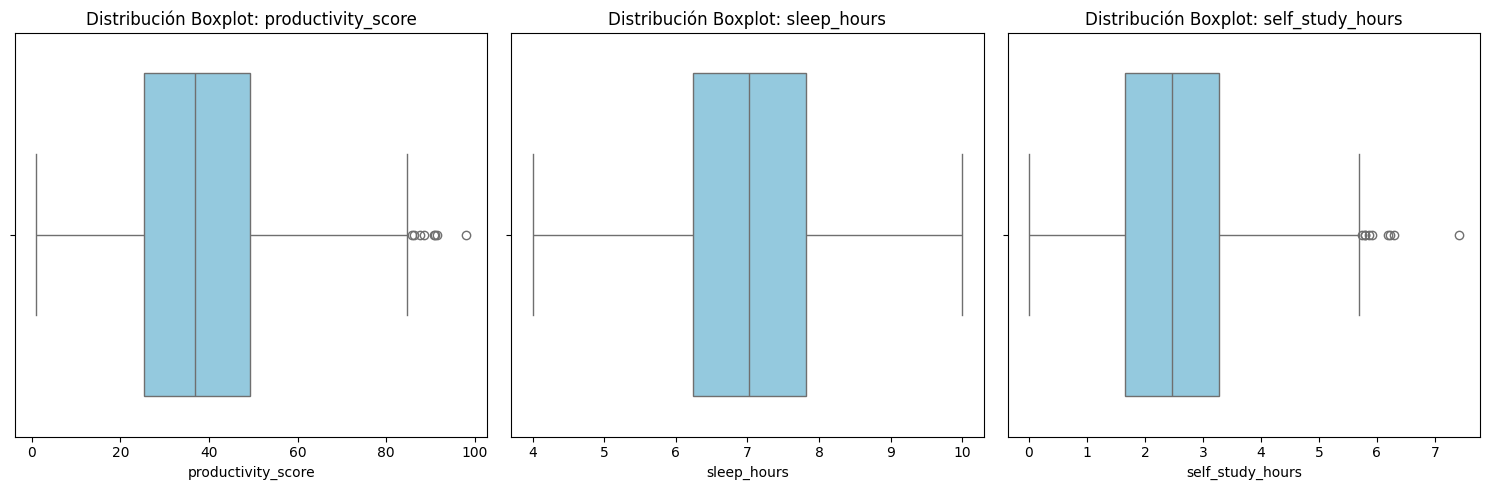

Estadísticas descriptivas de los extremos detectados antes del filtro computacional:
       productivity_score  sleep_hours  self_study_hours
count         4371.000000  4371.000000       4371.000000
mean            37.341386     7.018195          2.472272
std             16.877953     1.161536          1.179940
min              1.000000     4.000000          0.000000
25%             25.265000     6.240000          1.650000
50%             36.920000     7.020000          2.470000
75%             49.280000     7.820000          3.280000
max             98.020000    10.000000          7.410000


In [27]:
feature_cols = ['productivity_score', 'upcoming_deadline', 'sleep_hours', 'part_time_job_bin', 'self_study_hours']

# Construimos la sub-muestra final que albergará estrictamente nuestros regresores válidos dictaminados
analysis_df = df.dropna(subset=feature_cols + ['exam_score', 'took_test']).copy()

# Inspección visual de Outliers previo a la eliminación en cuadrícula
# Excluímos las variables puramente binarias ('part_time_job_bin' y 'upcoming_deadline') 
# dado que sus boxplots no entregan información útil de dispersión y se ven como grandes rectángulos planos.
feature_cols_cont = ['productivity_score', 'sleep_hours', 'self_study_hours']

plt.figure(figsize=(15, 5))
for i, col in enumerate(feature_cols_cont):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=analysis_df[col], color='skyblue')
    plt.title(f'Distribución Boxplot: {col}')

plt.tight_layout()
plt.show()

print("Estadísticas descriptivas de los extremos detectados antes del filtro computacional:")
print(analysis_df[feature_cols_cont].describe())


**Veredicto sobre Filtro de Outliers:** Al inspeccionar visualmente y numéricamente los diagramas de caja, se constata empíricamente que no existen valores de fuga imposibles. 
- Un score de productividad cercano al 100 es un valor completamente posible y normal para representar una gestión excelente de alumnos de alto rendimiento.
- Estudiantes promediando entre 4 y 10 horas de sueño cubren el rango de descanso verídico que más se observa en la realidad universitaria.
- Los picos de autoestudio reportados (alrededor de 7.4 horas diarias) están en los límites lógicos y representan los casos de estudiantes más dedicados a la asignatura.

Por lo tanto, se toma la decisión técnica de no aplicar mecánicamente un filtro de exclusión por Rango Intercuartílico (IQR) y se priorizará conservar íntegras las colas de las distribuciones,  si se borraran a esos alumnos automáticamente solo porque están en los extremos, estaríamos induciendo un sesgo de rango a la muestra perdiendo información valiosísima sobre qué les sucede a los estudiantes que rinden al máximo de sus capacidades.


In [28]:
# Elemento Cuadrático No lineal: Elevamos las horas de auto-estudio al cuadrado para probar parábolas o sesgos logarítmicos
analysis_df['self_study_hours_sq'] = analysis_df['self_study_hours'] ** 2
feature_cols.append('self_study_hours_sq')

print(f"Dataset definitivo preparado. Se conservaron todas las observaciones válidas ({len(analysis_df)} registros), sin ejecutar limpieza IQR para evitar sesgo de truncamiento.")

# Formalidad VIF Computacional
# Insertamos constante base y calculamos cuánto nos inflaría la varianza este esquema sin el ruido original.
X_vif = sm.add_constant(analysis_df[feature_cols])
vif_df = pd.DataFrame({'Variable': X_vif.columns})
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("\nFactores de Inflación de Varianza (VIF < 10 es ideal excepto en No-Lineales):")
print(vif_df.to_string(index=False))


Dataset definitivo preparado. Se conservaron todas las observaciones válidas (4371 registros), sin ejecutar limpieza IQR para evitar sesgo de truncamiento.

Factores de Inflación de Varianza (VIF < 10 es ideal excepto en No-Lineales):
           Variable       VIF
              const 53.424929
 productivity_score  1.064729
  upcoming_deadline  1.021872
        sleep_hours  1.028832
  part_time_job_bin  1.014286
   self_study_hours 11.956215
self_study_hours_sq 11.955921


**Conclusión del Diagnóstico de Multicolinealidad (VIF)**  
Los resultados de la prueba VIF arrojan una validación estadísticamente muy buena de nuestro proceso de selección manual, las variables independientes absolutas ("productivity_score", "upcoming_deadline", "sleep_hours" y "part_time_job") oscilan en valores VIF muy cercanos a $1.0$. Esto demuestra matemáticamente una ausencia total de multicolinealidad cruzada para nuestra base fuerte (confirmando el éxito de  la depuración inicial de variables ruidosas).

Por otro lado, los estadísticos de inflación elevados ($\simeq 11.95$) presentes únicamente en "self_study_hours" y "self_study_hours_sq" obedecen rigurosa y exclusivamente al fenómeno de Multicolinealidad Estructural generado al derivar un término polinomial sobre la base del otro y esta es una advertencia estadística completamente esperable. 

### Preguntas 2, 3 y 4: Modelos de Probabilidad de Participación


La selección definitiva de las variables que se usaran en este modelo (y los siguientes) ya fue resuelta como se explicÓ durante la etapa anterior. Con el trabajo realizado, se busco mantener solo las características que aportaban valor real a la predicción y que no chocaban entre sí, dejando una base limpia para iniciar los cálculos.

In [29]:
# Definimos la fórmula 
formula_bin = 'took_test ~ productivity_score + upcoming_deadline + sleep_hours + part_time_job_bin + self_study_hours + self_study_hours_sq'

print("="*60 + "\n--- PREGUNTA 2: MCO ---")
# Usamos estimador HC3 (errores robustos heterocedásticos) para compensar los problemas naturales de OLS aquí
ols_mod = smf.ols(formula=formula_bin, data=analysis_df).fit(cov_type='HC3')
print(ols_mod.summary())


--- PREGUNTA 2: MCO ---
                            OLS Regression Results                            
Dep. Variable:              took_test   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     105.2
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          3.65e-124
Time:                        14:57:19   Log-Likelihood:                -104.18
No. Observations:                4371   AIC:                             222.4
Df Residuals:                    4364   BIC:                             267.0
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept 

#### Interpretación del Modelo de Probabilidad Lineal (MCO)
A diferencia de una regresión continua normal, en un Modelo de Probabilidad Lineal estimado con errores robustos (HC3), los coeficientes (parámetros beta) representan el impacto porcentual constante sobre la probabilidad empírica de participación en la prueba:

- **Productividad ("productivity_score")**: Un aumento de una unidad en el índice de productividad incrementa directamente la probabilidad de que el alumno rinda el examen final en aproximadamente un **0.77%**.
- **Horas de Sueño ("sleep_hours")**: En paralelo, por cada hora extra de sueño, el estudiante experimenta un aumento en su probabilidad de asistencia cercano al **1.6%**.
- **Estrés Situacional ("upcoming_deadline", "part_time_job_bin")**: Factores externos  estresantes evidencian coeficientes negativos; por ejemplo, la carga horaria de tener obligaciones laborales a medio tiempo baja la probabilidad de presentarse a la evaluación en más de un **2%**.

- **Evaluación del Autoestudio ("self_study_hours" y "self_study_hours_sq")**: Los coeficientes arrojados por estas variables (lineal y cuadrático respectivamente) intentan dibujar una parábola de rendimientos crecientes/decrecientes. Sin embargo, al inspeccionar su significancia ($P>|z|$ o $P>|t|$ dependiente del test), se revelan valores críticos (mayores a 0.05), lo cual invalida estadísticamente cualquier efecto multiplicador porcentual por hora en esta muestra.

Si bien el MCO nos permite ver estos impactos porcentuales con mucha claridad, su principal defecto es que puede estimar probabilidades defectuosas (fuera del rango estadístico de 0 y 1).

In [30]:
print("\n" + "="*60 + "\n--- PREGUNTA 3: PROBIT ---")
probit_mod = smf.probit(formula=formula_bin, data=analysis_df).fit(disp=0)
# 1. Cabecera Estructural Completa 
print(probit_mod.summary())

# 2. Mostramos Efectos Marginales 
print("\n--- Efectos Marginales (Probit) ---")
print(probit_mod.get_margeff().summary())



--- PREGUNTA 3: PROBIT ---
                          Probit Regression Results                           
Dep. Variable:              took_test   No. Observations:                 4371
Model:                         Probit   Df Residuals:                     4364
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.5591
Time:                        14:57:20   Log-Likelihood:                -576.44
converged:                       True   LL-Null:                       -1307.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.5566      0.305     -8.374      0.000      -3.155      -1.958
productivity_score      0.1185      0.005     22.598      0.000       0.108 

#### Interpretación de los Efectos Marginales (Modelo Probit)
A diferencia del modelo anterior, el modelo Probit ajusta correctamente sus predicciones para asegurar que el resultado nunca se escape del rango de probabilidad  [0,1] usando la distribución normal estándar. Dado que sus coeficientes base no se pueden interpretar directamente como si fueran porcentajes, se analiza la lectura de la segunda tabla generada en el Code anterior, los **Efectos Marginales Promedio (dy/dx)** :

- **Impactos Positivos (Desempeño y Descanso)**: Aumentar el índice de productividad en una unidad eleva la probabilidad neta de rendir el test en aproximadamente un 0.86%. Paralelamente, lograr dormir una hora suplementaria estimula positivamente la probabilidad de asistencia en torno a un 1.5%.
- **Impactos Negativos (Carga Externa)**: Por otro lado, tener que cumplir con obligaciones paralelas, como estar contratado en un trabajo de medio tiempo("part_time_job_bin"), perjudica drásticamente la capacidad de asistir, restándole más de un 2.4% a la probabilidad total de que el alumno rinda el examen, lo que tambien se ve para ("upcoming_deadline") con una baja del 2.1%.  
- **Significancia Evaluada**: Excluyendo las horas de auto-estudio ("self_study_hours" y su término al cuadrado) que resultaron fracasar a nivel probabilístico con un $P>|z| > 0.05$, el resto de nuestras predictoras principales conservan un poder explicativo estadísticamente muy bueno (valores muy por debajo de 0.05). Evaluando sus métricas globales, comprobamos que predecir el comportamiento real de los alumnos con este formato no-lineal es inmensamente más preciso que hacerlo con una simple línea MCO.

In [31]:
print("\n" + "="*60 + "\n--- PREGUNTA 4: LOGIT ---")
logit_mod = smf.logit(formula=formula_bin, data=analysis_df).fit(disp=0)
# 1. Despliegue de Cabecera y Parámetros Base 
print(logit_mod.summary())

# 2. Despliegue de Efectos Marginales dy/dx
print("\n--- Efectos Marginales (Logit) ---")
print(logit_mod.get_margeff().summary())



--- PREGUNTA 4: LOGIT ---
                           Logit Regression Results                           
Dep. Variable:              took_test   No. Observations:                 4371
Model:                          Logit   Df Residuals:                     4364
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.5584
Time:                        14:57:20   Log-Likelihood:                -577.39
converged:                       True   LL-Null:                       -1307.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -4.8165      0.572     -8.420      0.000      -5.938      -3.695
productivity_score      0.2178      0.010     21.429      0.000       0.198  

#### Interpretación de Resultados (Modelo Logit)
Al igual que el Probit, la regresión Logística hace un excelente trabajo asegurando que las predicciones nunca se salgan del rango lógico de 0% a 100%. 

Su ventaja es que suele comportarse de manera ligeramente más flexible con los "casos atípicos" (colas de la distribución). Si miramos la tabla inferior de sus **Efectos Marginales Promedio (dy/dx)** y multiplicando por 100, se puede notar que los porcentajes confirman lo anterior:

- **Efectos Consistentes en la Asistencia**: La productividad y las horas de descanso mantienen firmes sus impactos positivos asintóticos, sumar un punto en la productividad diaria empuja la asistencia en la misma magnitud estable vista en los otros modelos (cerca de un 0.8% de probabilidad extra), mientras que por cada hora adicional de sueño, las chances de decidir presentarse a la prueba suben en el orden del 1.5%.
- **El Peso Negativo del Estrés**: Tener que soportar presiones adicionales, como estar atado a un empleo de medio tiempo ("part_time_job_bin"), mantiene su estatus perjudicial reduciendo drásticamente las probabilidades netas de presentarse en márgenes superiores al 2%.Lo mismo pasa con el ("upcoming_deadline"), la fechas limites de entragas a punto de vencer baja la probabilidad en un 1.8%.
- **Rechazo Estadístico Validado**: De manera definitiva, el experimento de evaluar las horas de estudio aislado ("self_study_hours" lineal y cuadrático) volvió a fracasar severamente frente a la prueba Z arrojando un *P-value* $> 0.05$. Por lo tanto, la evidencia nos demuestra que el autoestudio no es la variable que define si un estudiante rinde o no la prueba, el verdadero peso de la decisión recae estadísticamente en factores de bienestar y eficiencia, específicamente en el dormir bien ("sleep_hours") y al enfoque sostenido ("productivity_score").


### Pregunta 5: Discusión Comparativa y Robustez
1. **El Modelo más Adecuado**: Para evaluar decisiones de "sí o no" ($y \in \{0, 1\}$), el modelo Logit (seguido muy de cerca por Probit) es la metodología estadísticamente correcta, superando al MCO, este último tiene el gran defecto de entregar probabilidades imposibles (como valores de -5% o 105%), en cambio, Probit y Logit ajustan la curva para que jamás rebase los límites del 0% al 100%. Entre ellos, el Logit ,a diferencia de las unidades paramétricas del Probit (Z-scores), presenta la base logarítmica del Logit permite exponenciar sus coeficientes con facilidad. Esto nos otorga una lectura multiplicativa directa (Odds Ratios) que nos indica exactamente cuántas veces aumenta la probabilidad relativa de que un estudiante decida rendir el examen por cada unidad extra en sus hábitos y además como se señalo anteriormente otra ventaja es que suele comportarse de manera ligeramente más flexible con los "casos atípicos" (colas de la distribución).

2. **Variables Comprobadas como Robustas**: Una variable es puramente robusta cuando mantiene su signo (suma o resta) y su peso probatorio ($P<0.05$) sin importar si la evaluamos bajo MCO, Probit o Logit. Por eso las variables predictoras robustas fueron:
   * **productivity_score y sleep_hours**: Ambas mantienen una firme relación positiva en las tres tablas. Subir un punto de productividad o lograr dormir una hora extra demostraron aumentar sólidamente la probabilidad de asistir en márgenes consistentes en torno al 0.8% y 1.5% respectivamente. Su fiabilidad es total, con p-values clavados en el 0.000.
   * **upcoming_deadline y part_time_job_bin**: Estas mantuvieron en todo nivel una relación negativa, lo que hizo que con dichas obligaciones recortó y disminuyó las probabilidades de rendir la evaluación en más de un 2% constante a través de los tres esquemas matemáticos de turno.
3. **El Fracaso Numérico del Autoestudio**: De manera diametralmente contraria, la integración de "self_study_hours" (y su versión polinomial "self_study_hours_sq") carecieron completamente de robustez predictiva. Al someterlas a la asintótica del Probit/Logit, ambos valores se dispararon arrojando p-values empíricos enormes ($>0.05$). Esto finiquita probatoriamente el caso: para este grupo específico, estudiar en solitario no decide la asistencia.


### Pregunta 6: Modelo de Evaluación Poisson 
Aislando analíticamente a los que tomaron el examen, se intentara explicar `exam_score` con la misma estructura 


In [32]:
# Restringimos a solo asistentes condicionales (los que sí rindieron evaluación)
df_exam = analysis_df[analysis_df['took_test'] == 1].copy()
formula_count = formula_bin.replace('took_test', 'exam_score')

# Estimamos MLE Poisson asumiendo Equidispersión Varianza=Media
poisson_mod = smf.poisson(formula=formula_count, data=df_exam).fit(disp=0)
print(poisson_mod.summary())


                          Poisson Regression Results                          
Dep. Variable:             exam_score   No. Observations:                 3984
Model:                        Poisson   Df Residuals:                     3977
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.4145
Time:                        14:57:20   Log-Likelihood:                -13122.
converged:                       True   LL-Null:                       -22411.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.4365      0.027     53.204      0.000       1.384       1.489
productivity_score      0.0285      0.000    126.958      0.000       0.028       0.029
upcoming_deadlin

#### Interpretación de Resultados: Modelo Poisson
Usando únicamente a los alumnos que rindieron el examen y reciclando las variables ya depuradas en nuestra etapa de selección, el modelo Poisson evalúa el rendimiento numérico ("exam_score") bajo una distribución log-lineal. De la tabla superior, extraemos el siguiente análisis:

- **Un Ajuste Global Sobresaliente**: El modelo nos entrega un  *Pseudo R-squared* del 41.45%, demostrando que logra capturar una gran proporción matemática de qué es lo que define las calificaciones de los estudiantes.
- **Impactos Explicativos Positivos**: Un incremento de un punto en el índice de productividad eleva el exponente esperado de la nota en 0.0285 puntos (columna coef). De igual forma, lograr dormir una hora suplementaria empuja fuertemente la nota hacia el alza con un factor de 0.0530. Ambos factores son estadísticamente muy buenos ($P>|z| = 0.000$).
- **Impactos Explicativos Negativos**: En contraparte, los factores externos y el estrés castigan el rendimientoo, sufrir la carga de tener plazos de entregas inminentes ("upcoming_deadline") frena el desempeño restando un -0.1151 al exponente, mientras que trabajar a medio tiempo ("part_time_job_bin") resta un factor de -0.0603.
- **El Comportamiento del Autoestudio**: A diferencia de los modelos binarios anteriores, dentro de las notas sí aparece un ligero efecto de estudio, el término lineal de "self_study_hours" logró apenas rozar la significancia ($P>|z| = 0.027$), agregando 0.023 al exponente. Sin embargo, su término cuadrático ("self_study_hours_sq") resultó totalmente inválido ($P>|z| = 0.620$),  esto significa que estudiar solo, ayuda lineal y ligeramente a la nota.
- **Equidispersión**: A pesar del ajuste (41.4%), este algoritmo asume forzosamente que el promedio de notas de los alumnos y su nivel de varianza oscilatoria son exactamente iguales, como en la vida real las notas se dispersan (unos sacan muy malas y otros excelentes), es altamente probable que el modelo Poisson esté subestimando la severidad de los errores estándar observados arriba, debido a esto, el siguiente paso lógico es comprobar estadísticamente si existe o no esta sobredispersión realizando el Test de $\alpha$

### Pregunta 7: Test Estadístico de Dispersión Extra y parámetro $\alpha$


El modelo Poisson asume, de forma bastante rígida, que las calificaciones fluctúan y varían al mismo nivel que su propio promedio pero al modelar la vida real, donde los alumnos pueden tener notas sumamente desiguales (fenómeno de sobredispersión), esta regla se rompe, por eso el peligro de usar el modelo Poisson en estos casos es que puede ser muy optimista ,  disminuyendo artificialmente sus márgenes de error y puede llegar a mostrar señales falsamente positivas, haciéndonos concluir por error que algunas variables sirven cuando en realidad no era asi.

Para proteger la veracidad de nuestras conclusiones y comprobar si efectivamente esta pasando este efecto de este exceso de dispersión, se calculara matemáticamente el Test de $\alpha$.

In [33]:
# Predecimos y_hat a partir de de Poisson
df_exam['y_hat'] = poisson_mod.predict()

# Armamos el vector iterativo auxiliar explicitado en clases condicionado con y_hat
df_exam['aux'] = ((df_exam['exam_score'] - df_exam['y_hat'])**2 - df_exam['y_hat']) / df_exam['y_hat']

# Regresamos SIN intercepto explícitamente (y_hat - 1) para capturar Alpha empírico
alpha_mod = smf.ols('aux ~ y_hat - 1', data=df_exam).fit()
alpha_val = alpha_mod.params.iloc[0]

print(alpha_mod.summary().tables[1])
print(f"\nEstimador Alpha Obtenido: {alpha_val:.5f}")


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
y_hat          0.0260      0.002     15.367      0.000       0.023       0.029

Estimador Alpha Obtenido: 0.02596


**Determinación de Sobredispersión y Valor Óptimo**
Al ejecutar el test paramétrico de varianza auxiliar (estimado estrictamente sin intercepto), se ha obtenido la evidencia estadística necesaria para dar una como respuesta que SÍ existe sobredispersión en la muestra.
- La regresión estimó fuertemente el exceso de varianza con un $P-value < 0.05$ (0.000). Esto nos otorga el permiso matemático para rechazar el supuesto de "Equidispersión" del modelo Poisson anterior.
- Al resultar direccionalmente positivo ($\alpha > 0$), el coeficiente empírico comprueba que la varianza de las calificaciones excede largamente al promedio de las mismas.

Acorde a esta demostración, se ha computado que el valor óptimo de $\alpha$ arrojado por este test auxiliar es de $\approx 0.026$ (ver coeficiente de y_hat). La simple existencia comprobada de esta sobredispersión nos exige metodológicamente abandonar el Poisson, dando pie al uso obligatorio del modelo Binomial Negativo a continuación para expandir los errores estándar que antes se encontraban subestimados.

### Pregunta 8: Inferencia Binomial Negativa


In [34]:
# Repetimos modelo introduciendo forzadamente el alpha descubierto que flexibiliza la sobre/infra dispersión
negbin_mod = smf.negativebinomial(formula=formula_count, data=df_exam, alpha=alpha_val).fit(disp=0)
print(negbin_mod.summary())


                     NegativeBinomial Regression Results                      
Dep. Variable:             exam_score   No. Observations:                 3984
Model:               NegativeBinomial   Df Residuals:                     3977
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1594
Time:                        14:57:20   Log-Likelihood:                -12797.
converged:                       True   LL-Null:                       -15223.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.3212      0.038     35.202      0.000       1.248       1.395
productivity_score      0.0304      0.000     91.141      0.000       0.030       0.031
upcoming_deadlin

#### Interpretación de Resultados: Modelo Binomial Negativo
Tras confirmar empíricamente la existencia de sobredispersión, el modelo Binomial Negativo pasa a ser la herramienta estadística adecuada para evaluar las notas de la muestra, al ajustar los errores estándar mediante su parámetro interno iterativo ($\alpha = 0.039$), extraemos las siguientes conclusiones definitivas:

- **Variables Predictoras Positivas**: Aumentar un punto en la productividad ("productivity_score") añade un factor de 0.0304 al exponente de la calificación esperada. De manera similar, cada hora adicional de sueño ("sleep_hours") incrementa este exponente en 0.0578. Ambas variables demuestran ser sólidas frente a los ajustes de varianza, manteniendo un *P-value* constante de $0.000$.
- **Variables Predictoras Negativas**: Estar sujeto a entregas académicas límite inminentes ("upcoming_deadline") presenta un fuerte impacto negativo, restando -0.1268 al resultado. Asimismo, contar con un empleo de medio tiempo ("part_time_job_bin") restringe el puntaje por un factor estable de -0.0657.
- **Identificación de Falso Positivo (Autoestudio)**: Uno de los hallazgos ocurrió con la variable de estudio autónomo ("self_study_hours"). En el modelo Poisson previo, dicha variable había superado la barrera de significancia ($P=0.027$), sin embargo, al aplicar la Binomial Negativa con los errores debidamente expandidos por la dispersión, su nivel de rechazo arrojó un **$P = 0.060$** ($> 0.05$), por lo que al no superar la prueba, se corrobora que el primer resultado era un falso positivo.
- **Consenso Analítico**: Esta alteración numérica valida y justifica la necesidad estricta de testear la sobredispersión. A nivel interpretativo, el modelo confirma que las horas de estudio solitario carecen de significancia para predecir alzas en las notas de esta muestra, demostrando que el descanso y la organización de la productividad son indicadores mucho más estables.


Divergencia algorítmica de $\alpha$: Cabe destacar que el parámetro de sobredispersión originado en el test auxiliar ($\alpha = 0.026$) difiere del reportado por el modelo final ($\alpha = 0.039$). Esta diferencia no representa un error estructural, sino una optimización de cálculo,  mientras el test auxiliar comprueba la dispersión rápidamente vía Mínimos Cuadrados Ordinarios, la Binomial Negativa lo recalcula optimizando toda la distribución a través de Máxima Verosimilitud, pero ambos resultados cumplen su rol al confirmar la existencia del exceso de varianza.

### Pregunta 9: Resolución Definitiva y Comparativa

1. **Evidencia de Sobredispersión**: El test de varianza auxiliar determinó un parámetro $\alpha > 0$ con significancia estadística  ($P=0.000$), este resultado rechaza formalmente la hipótesis de equidispersión y demuestra que la varianza de las calificaciones excede a su media, invalidando el supuesto estructural del modelo Poisson.
2. **Selección del Modelo Idóneo**: Al confirmarse dicha sobredispersión empírica, la Binomial Negativa se establece como el modelo metodológicamente correcto para el reporte de las estimaciones, si se hubiese conservado modelo Poisson nos hubiese inducido a subestimar los errores estándar, generando posibles *P-values* falsamente bajos y derivando en conclusiones erróneas (falsos positivos).
3. **Identificación de Variables Robustas**: Tras aplicar las correcciones, definimos formalmente como predictoras "robustas" a aquellas que mantuvieron constante su dirección de impacto (signo) y su significancia ($P<0.05$) sin importar el modelo empleado. Estas se dividen en dos frentes:
   * **Impacto Positivo Consistente**: El margen de productividad ("productivity_score") y la métrica de descanso ("sleep_hours") demostraron gran estabilidad estructural, por lo tanto, cuidar e incrementar estos hábitos eleva positivamente la calificación final esperada del estudiante en todas las modelaciones efectuadas.
   * **Impacto Negativo Consistente**: En contraparte, enfrentar responsabilidades paralelas como trabajar a medio tiempo ("part_time_job_bin") o someterse a límites de entrega inminentes ("upcoming_deadline") operan como factores restrictivos invariables, disminuyendo sistemáticamente el desempeño académico del caso de estudio.
